# 02 · Behavioral evaluation & nulls

Before trusting a behavioral score, check it against two floors: **chance** (0.5
for a balanced two-way task) and a **random-feature readout** (what a logistic
head overfits from a randomly-initialized network). A score inside the
random-feature band is reporting noise, not brain-relevant signal.

Balanced accuracy: 0.5 = chance, 1.0 = perfect, higher is better. This is a
self-contained illustration of the null-comparison logic; production ROAR scoring
is EC2-only.

## A toy two-way task

60 stimuli (30 per class), split into train and held-out test — a stand-in for ROAR's real-vs-pseudo lexical decision.

In [1]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score

# A balanced 2-class problem: 60 stimuli, 64 feature dims, alternating labels.
rng = np.random.RandomState(0)
n, d = 60, 64
y = np.array([0, 1] * (n // 2))
tr, te = np.arange(0, 40), np.arange(40, 60)    # 40 train / 20 held-out (no overlap)
print(f'{n} stimuli, 2 classes; {len(tr)} train / {len(te)} held-out')

60 stimuli, 2 classes; 40 train / 20 held-out


## Random-feature null (a distribution, not one number)

200 randomly-initialized feature sets, each read out by a logistic head and scored on held-out data. Random features carry no real signal, so they land near chance — the spread is the null band.

In [2]:
def readout_accuracy(features):
    '''Fit a logistic readout on the train split, score balanced accuracy on held-out.'''
    clf = LogisticRegression(max_iter=500).fit(features[tr], y[tr])
    return balanced_accuracy_score(y[te], clf.predict(features[te]))

# The null: 200 readouts trained on PURE NOISE features (nothing to learn).
null = np.array([readout_accuracy(np.random.RandomState(s).randn(n, d)) for s in range(200)])
lo, med, hi = np.percentile(null, [5, 50, 95])   # 5-95% band + median of the null
print(f'random-feature null: median {med:.2f}, 5-95% band [{lo:.2f}, {hi:.2f}]')

random-feature null: median 0.50, 5-95% band [0.30, 0.70]


## A readout with real signal

Same logistic head, but now one feature actually tracks the label (plus noise). This should clear the null band.

In [3]:
# A feature matrix with exactly one informative dimension (dim 0 tracks the label).
signal = rng.randn(n, d)
signal[:, 0] += 3.0 * (y - 0.5)                  # push class 1 up, class 0 down on dim 0
model_score = readout_accuracy(signal)
print(f'signal readout: {model_score:.2f}   (null upper edge {hi:.2f})')
print('clears the null band:', model_score > hi)

signal readout: 0.80   (null upper edge 0.70)
clears the null band: True


## The comparison, as a plot

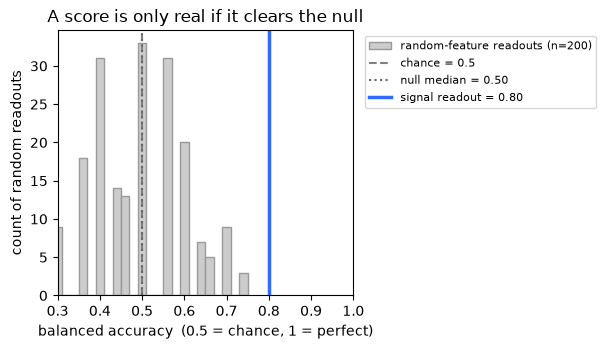

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.2, 3.6))
# distribution of the 200 random-feature readouts (the null)
ax.hist(null, bins=25, color='0.8', edgecolor='0.6', label='random-feature readouts (n=200)')
ax.axvline(0.5, ls='--', c='gray', label='chance = 0.5')
ax.axvline(med, ls=':', c='0.4', label=f'null median = {med:.2f}')
# where the real signal readout falls (well to the right of the null)
ax.axvline(model_score, c='#2f6bff', lw=2.5, label=f'signal readout = {model_score:.2f}')
ax.set_xlim(0.3, 1.0)
ax.set_xlabel('balanced accuracy  (0.5 = chance, 1 = perfect)')
ax.set_ylabel('count of random readouts')
ax.set_title('A score is only real if it clears the null')
# legend just outside the axes so it never sits on the bars or the score line
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1))
fig.tight_layout(); plt.show()

**Reading it:** the grey band is where random features land — any score inside it
is noise. Chance (0.5) is the floor for a balanced task. The signal readout sits
above the band, so its accuracy reflects real structure. On a real benchmark you
run the same check with `random-vit-b-32` and `chance-baseline` as the nulls.